In [1]:
import os, json, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from torch.utils.data import DataLoader
from data_preprocess import load_and_prepare_data
from dataset import ValDataset, HOURS_IN_WEEK
from model import TimeSeriesTFM

In [2]:
# -------- 1. 參數定義 --------
model_dir = "models/20250603_012334"   # 指定模型資料夾
STEP      = 169                         # 每幾小時取一筆樣本（1 = 不抽稀）

In [3]:
# -------- 2. 載入 config / scaler --------
with open(os.path.join(model_dir, "config.json")) as f:
    cfg = json.load(f)
with open(os.path.join(model_dir, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)

# 根據 input_dim 決定特徵欄
if cfg.get("input_dim", 3) == 7:
    FEATS = ["Tx","RH","PrecpHour","h_sin","h_cos","dow_sin","dow_cos"]
else:
    FEATS = ["Tx","RH","PrecpHour"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 允許的模型引數
allowed = {
    "input_dim","output_dim",
    "d_model","nhead","num_layers",
    "dim_feedforward","dropout"
}
model = TimeSeriesTFM(**{k:v for k,v in cfg.items() if k in allowed}).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(model_dir,"best.pt"), map_location=DEVICE))
model.eval(); print("DEVICE:", DEVICE)

DEVICE: cuda


In [4]:
# -------- 3. 讀 2024-2025 原始資料 --------
raw_df = load_and_prepare_data(["Data/466920_2024.csv","Data/466920_2025.csv"]).copy()

# 確保有時間週期特徵
if "h_sin" not in raw_df.columns:
    from train_optuna import add_time_features
    raw_df = add_time_features(raw_df)

start_date = pd.Timestamp("2025-05-21 00:00:00")
end_date   = raw_df["DateTime"].max() + pd.Timedelta(hours=1)
mask_eval  = (raw_df["DateTime"] >= start_date) & (raw_df["DateTime"] < end_date)
dt_eval    = raw_df.loc[mask_eval, "DateTime"].values
N_eval     = len(dt_eval)
print("評估範圍：", start_date, "~", end_date - pd.Timedelta(hours=1), ",", N_eval, "hours")

c:\Users\EricWeng\Documents\Python\AIOTLAB\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


評估範圍： 2025-05-21 00:00:00 ~ 2025-05-29 00:00:00 , 193 hours


In [5]:
# -------- 4. 標準化 & Dataset --------
work_df = raw_df.copy()
work_df[FEATS] = scaler.transform(work_df[FEATS])

def collate(b): xs, ys = zip(*b); return torch.tensor(xs), torch.tensor(ys)
valset = ValDataset(work_df, str(start_date), str(end_date), feat_cols=FEATS)
loader = DataLoader(valset, batch_size=1, shuffle=False, collate_fn=collate)

# -------- 5. 緩衝區 --------
keep_cols = 3  # 只繪 Tx/RH/Precp
pred_sum = np.zeros((N_eval, keep_cols))
pred_cnt = np.zeros((N_eval, 1))
true_buf = raw_df.loc[mask_eval, ["Tx","RH","PrecpHour"]].values
sqe  = np.zeros((keep_cols, 168)); cntR = np.zeros((keep_cols, 168))

In [6]:
# -------- 6. 逐步預測 --------
with torch.no_grad():
    for k, (X, Y) in enumerate(loader):
        if k % STEP: continue
        X, Y = X.to(DEVICE), Y.to(DEVICE)
        glb = valset.targets_idx[k]
        rel_start = np.where(mask_eval.values)[0].tolist().index(glb)
        rel_end   = min(rel_start + Y.size(1), N_eval)

        out_std = model.generate(X, horizon=Y.size(1))
        out_full  = scaler.inverse_transform(out_std.cpu().numpy()[0])
        true_full = scaler.inverse_transform(Y.cpu().numpy()[0])

        out  = out_full[:, :keep_cols]
        true = true_full[:, :keep_cols]
        out, true = out[:rel_end-rel_start], true[:rel_end-rel_start]

        pred_sum[rel_start:rel_end] += out
        pred_cnt[rel_start:rel_end] += 1
        err2 = (out - true) ** 2
        h = err2.shape[0]
        sqe[:, :h]  += err2.T
        cntR[:, :h] += 1

avg_pred = pred_sum / np.where(pred_cnt == 0, 1, pred_cnt)
rmse = np.sqrt(sqe / cntR)

,WeeklyAvg_RMSE,First24h_RMSE,Last24h_RMSE
Tx (°C),4.299,2.455,3.613
RH (%),9.376,8.935,5.455
PrecpHour (mm),0.142,0.015,0.064


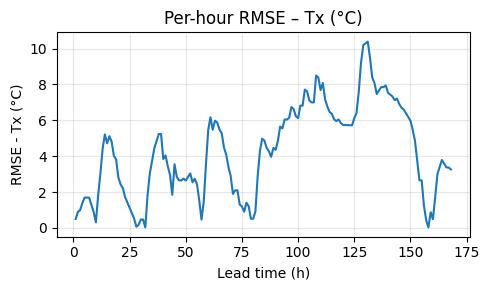

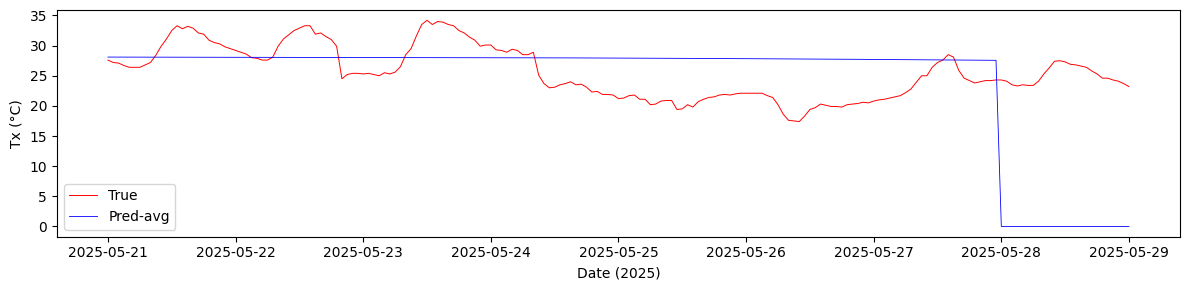

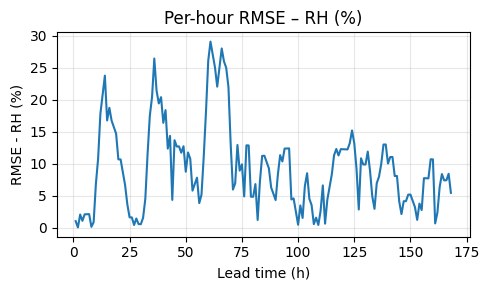

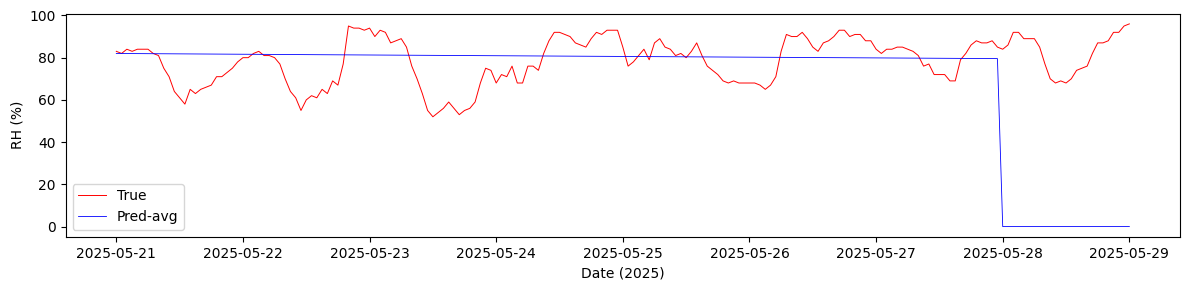

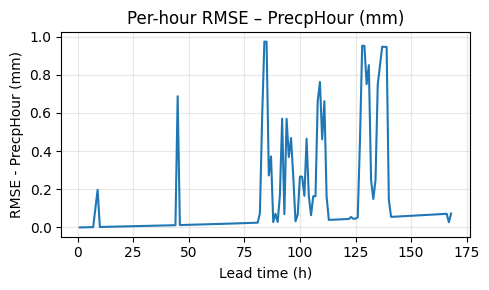

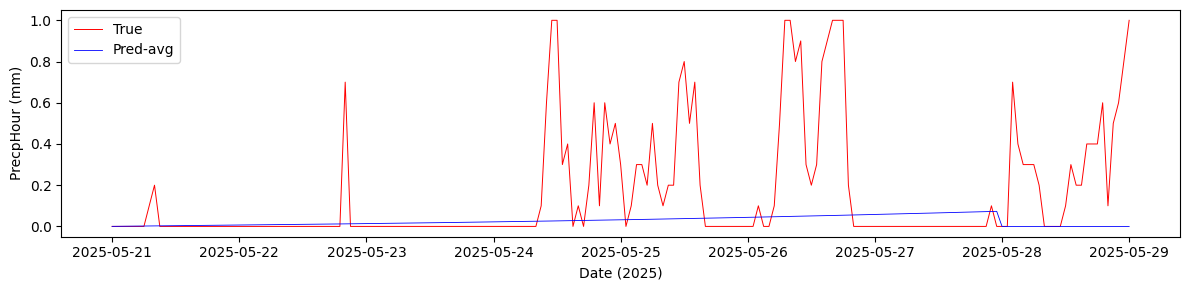

In [7]:
# -------- 7. 顯示結果 --------
names = ["Tx (°C)", "RH (%)", "PrecpHour (mm)"]
summary = pd.DataFrame({
    "WeeklyAvg_RMSE": rmse.mean(axis=1),
    "First24h_RMSE":  rmse[:, :24].mean(axis=1),
    "Last24h_RMSE":   rmse[:, -24:].mean(axis=1)
}, index=names).round(3)
display(summary)

rmse_png = ["rmse_tx.png","rmse_rh.png","rmse_precp.png"]
time_png = ["timeline_tx.png","timeline_rh.png","timeline_precp.png"]
hours = range(1, 169)

for i in range(keep_cols):
    # RMSE by lead time
    plt.figure(figsize=(5,3))
    plt.plot(hours, rmse[i]); plt.grid(alpha=.3)
    plt.xlabel("Lead time (h)"); plt.ylabel(f"RMSE - {names[i]}")
    plt.title(f"Per-hour RMSE – {names[i]}"); plt.tight_layout()
    plt.savefig(os.path.join(model_dir, rmse_png[i])); plt.show()

    # Timeline true vs. pred-avg
    plt.figure(figsize=(12,3))
    plt.plot(dt_eval, true_buf[:,i], 'r', label="True", lw=.7)
    plt.plot(dt_eval, avg_pred[:,i], 'b', label="Pred-avg", lw=.6)
    plt.legend(); plt.ylabel(names[i]); plt.xlabel("Date (2025)")
    plt.tight_layout()
    plt.savefig(os.path.join(model_dir, time_png[i])); plt.show()